# Lab 7


## Principal Component Analysis(PCA)
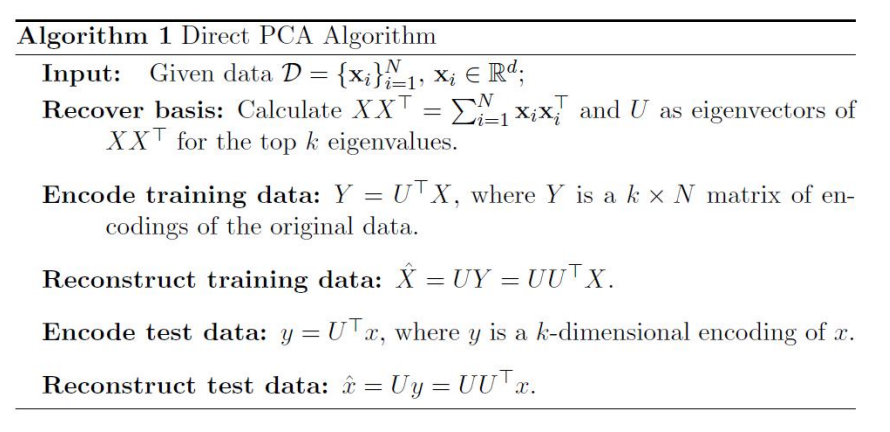

In [21]:
import numpy as np
import cv2 as cv
from math import pi
from matplotlib import pyplot as plt
from matplotlib.pyplot import figure, gca, imshow, plot, show, subplot
from sklearn import datasets
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # 3D绘图必备
from sklearn.manifold import Isomap
import torch


Original data shape: (500, 2)

PCA Components (Eigenvectors):
 [[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]
Explained Variance (Eigenvalues): [1.79433947 0.20966855]
Explained Variance Ratio: [0.89537539 0.10462461]


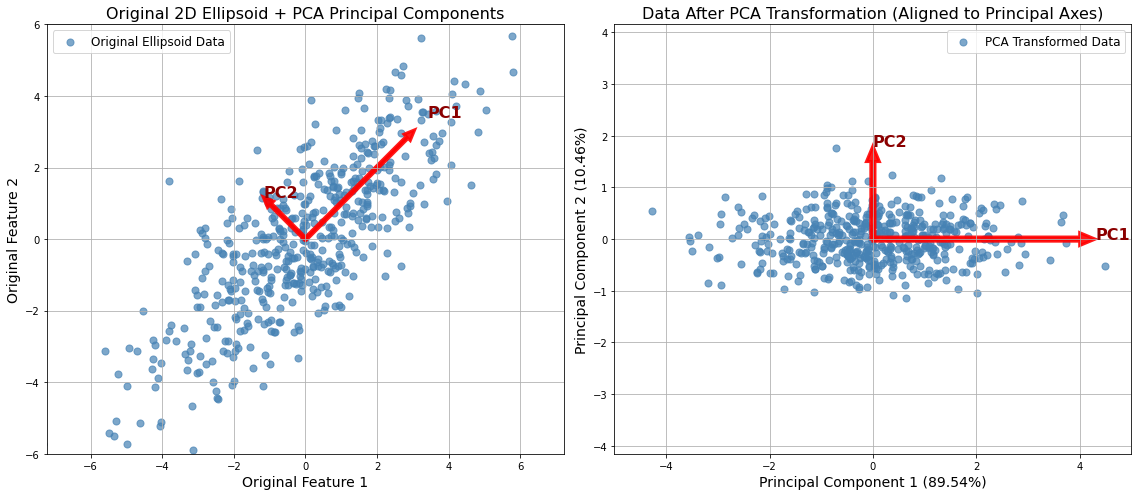

In [15]:
# Set random seed for reproducibility
np.random.seed(42)
n_samples = 500


# Define a clearly stretched ellipsoid (long axis at ~45 degrees)
mean = [0, 0]
# Covariance matrix creates a strong correlation, stretching the data along y=x
cov = [
    [5, 4],
    [4, 5]
]
# Generate data from multivariate normal distribution (this is our ellipsoid)
X = np.random.multivariate_normal(mean, cov, n_samples)
print("Original data shape:", X.shape)


# Standardize the data (required for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Perform PCA to get 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Get PCA components (eigenvectors) and explained variance (eigenvalues)
components = pca.components_  # Shape: (2, 2), rows are PC1, PC2
explained_variance = pca.explained_variance_  # Eigenvalues (variance along each PC)
explained_variance_ratio = pca.explained_variance_ratio_

print("\nPCA Components (Eigenvectors):\n", components)
print("Explained Variance (Eigenvalues):", explained_variance)
print("Explained Variance Ratio:", explained_variance_ratio)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))


# Plot original data (the ellipsoid)
ax1.scatter(X[:, 0], X[:, 1], color='steelblue', alpha=0.7, s=50, label='Original Ellipsoid Data')

# Draw PCA arrows (in ORIGINAL feature space, aligned to ellipsoid axes)
# Scale arrows by sqrt(variance) to make length proportional to standard deviation
scale = 3
for i, (comp, var) in enumerate(zip(components, explained_variance)):
    # Arrow direction = component vector, length = sqrt(variance) * scale
    dx = comp[0] * np.sqrt(var) * scale
    dy = comp[1] * np.sqrt(var) * scale
    
    ax1.arrow(0, 0, dx, dy, color='red', alpha=0.9,
              linewidth=3, width=0.08, head_width=0.25, head_length=0.3)
    
    ax1.text(dx * 1.2, dy * 1.2, f'PC{i+1}',
             color='darkred', fontweight='bold', fontsize=16)

# Format subplot 1
ax1.set_title('Original 2D Ellipsoid + PCA Principal Components', fontsize=16)
ax1.set_xlabel('Original Feature 1', fontsize=14)
ax1.set_ylabel('Original Feature 2', fontsize=14)
ax1.legend(fontsize=12)
ax1.grid(True)
ax1.axis('equal')  # Critical: ensures ellipsoid shape is not distorted
ax1.set_xlim(-6, 6)
ax1.set_ylim(-6, 6)

# ---------------------- Subplot 2: PCA Transformed Data (Aligned to Axes) ----------------------
# Plot data after PCA transformation (aligned to PC1/PC2 axes)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], color='steelblue', alpha=0.7, s=50, label='PCA Transformed Data')

# Draw aligned PCA axes (now along x/y axes)
ax2.arrow(0, 0, 4, 0, color='red', alpha=0.9,
          linewidth=3, width=0.08, head_width=0.25, head_length=0.3)
ax2.text(4.3, 0, 'PC1', color='darkred', fontweight='bold', fontsize=16)

ax2.arrow(0, 0, 0, 1.5, color='red', alpha=0.9,
          linewidth=3, width=0.08, head_width=0.25, head_length=0.3)
ax2.text(0, 1.8, 'PC2', color='darkred', fontweight='bold', fontsize=16)

# Format subplot 2
ax2.set_title('Data After PCA Transformation (Aligned to Principal Axes)', fontsize=16)
ax2.set_xlabel(f'Principal Component 1 ({explained_variance_ratio[0]*100:.2f}%)', fontsize=14)
ax2.set_ylabel(f'Principal Component 2 ({explained_variance_ratio[1]*100:.2f}%)', fontsize=14)
ax2.legend(fontsize=12)
ax2.grid(True)
ax2.axis('equal')
ax2.set_xlim(-5, 5)
ax2.set_ylim(-5, 5)

plt.tight_layout()
plt.show()

Shape of X: (500, 3)


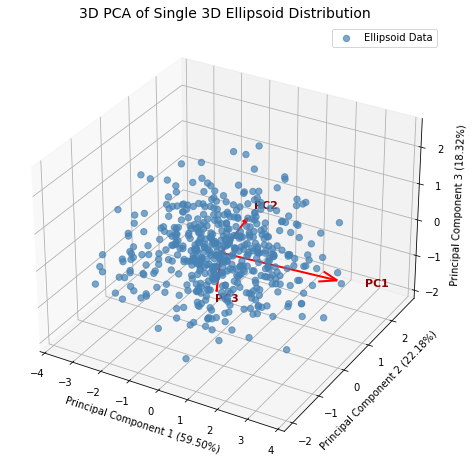

Explained variance ratio per component: [0.59501494 0.22180247 0.18318259]
Cumulative explained variance: [0.59501494 0.81681741 1.        ]


In [11]:
# Generate single 3D ellipsoid distribution data
np.random.seed(37)
n_samples = 500

# Mean and covariance for ONE ellipsoid cluster
mean = [0, 0, 0]
cov = [
    [5, 2, 1],
    [2, 3, 1],
    [1, 1, 2]
]

# Generate single 3D ellipsoid data
X = np.random.multivariate_normal(mean, cov, n_samples)
print("Shape of X:", X.shape)

# Standardize data
X_scaled = StandardScaler().fit_transform(X)

# PCA: keep 3 dimensions
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 3D Visualization
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot single ellipsoid scatter
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
           color='steelblue', alpha=0.7, s=40, label='Ellipsoid Data')

# Draw principal component arrows (red)
for i, (comp, var) in enumerate(zip(pca.components_.T, pca.explained_variance_ratio_)):
    comp = comp * var * 6
    ax.quiver(0, 0, 0, comp[0], comp[1], comp[2],
              color='red', linewidth=2, arrow_length_ratio=0.15)
    ax.text(comp[0]*1.25, comp[1]*1.25, comp[2]*1.25,
            f'PC{i+1}', color='darkred', fontweight='bold', fontsize=11)

# Title and labels
ax.set_title('3D PCA of Single 3D Ellipsoid Distribution', fontsize=14)
ax.set_xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
ax.set_ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
ax.set_zlabel(f'Principal Component 3 ({pca.explained_variance_ratio_[2]*100:.2f}%)')

ax.legend(loc='best')
ax.grid(True)
plt.show()

# Print variance information
print("Explained variance ratio per component:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", np.cumsum(pca.explained_variance_ratio_))

## Manifold Learning

Manifold learning is a class of nonlinear dimensionality reduction techniques.It assumes that high-dimensional data actually lies on or near a low-dimensional, smooth, curved structure called a manifold (e.g., a Swiss roll, S-curve, or sphere).

### Core Principle

Real-world high-dimensional data is often intrinsically low-dimensional.
Linear methods like PCA fail because they only capture global Euclidean distance, not the true geometry of the curved manifold.
Manifold methods preserve local neighborhood structure and estimate geodesic distances (shortest path along the curved surface) to unfold or flatten the manifold into a low-dimensional space.

### Typical Methods
#### Isomap
Computes geodesic distances between all pairs using neighborhood graphs, then applies metric MDS to embed into low dimensions.
Locally Linear Embedding (LLE)
Reconstructs each point from its neighbors, then finds a low-dimensional embedding that preserves the same linear reconstruction weights.
#### t-SNE
Focuses on clustering and visualization by modeling similarities in high and low dimensions with probability distributions, excellent for separating clusters.

### Summary
Manifold learning uncovers the hidden low-dimensional structure in high-dimensional data by respecting its nonlinear, curved geometry — something linear methods cannot do.

Original 3D data shape: (1500, 3)


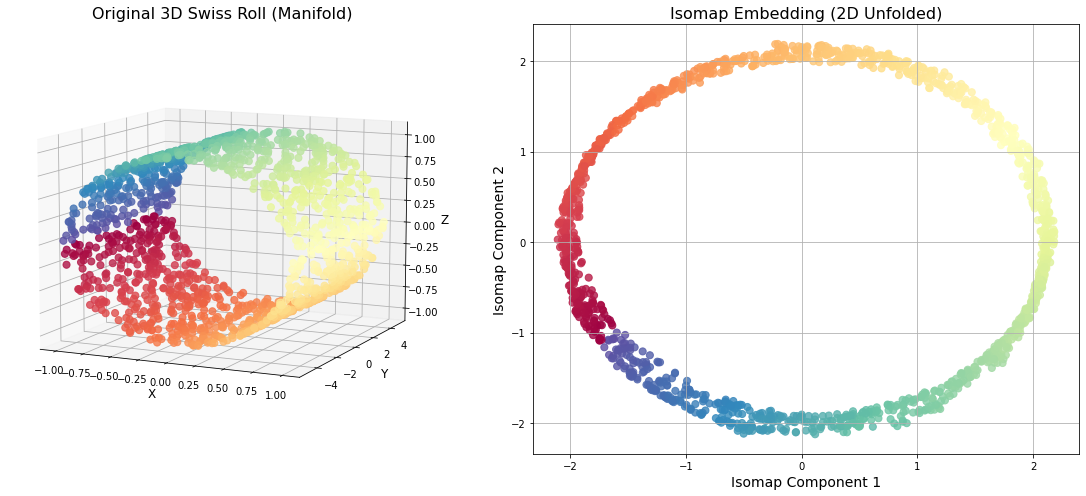

In [17]:
# Set random seed for reproducibility
np.random.seed(42)
n_samples = 1500

# ---------------------- Step 1: Generate Swiss Roll Data (3D Manifold) ----------------------
# Create "rolled" data in 3D space
t = np.random.rand(n_samples) * 2 * np.pi - np.pi  # Angle (roll length)
h = np.random.rand(n_samples) * 10 - 5             # Height (roll thickness)
X = np.array([np.cos(t), h, np.sin(t)]).T          # Roll shape
print("Original 3D data shape:", X.shape)

# Standardize data (Isomap is sensitive to scale)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ---------------------- Step 2: Apply Isomap to Unfold the Roll ----------------------
# n_neighbors: number of neighbors for geodesic distance calculation
# n_components: reduce to 2 dimensions
isomap = Isomap(n_neighbors=12, n_components=2)
X_isomap = isomap.fit_transform(X_scaled)

# ---------------------- Step 3: Visualization (3D Original vs 2D Isomap) ----------------------
fig = plt.figure(figsize=(16, 7))

# Subplot 1: Original 3D Swiss Roll
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], c=t, cmap=plt.cm.Spectral, s=50, alpha=0.8)
ax1.set_title('Original 3D Swiss Roll (Manifold)', fontsize=16)
ax1.set_xlabel('X', fontsize=12)
ax1.set_ylabel('Y', fontsize=12)
ax1.set_zlabel('Z', fontsize=12)
ax1.view_init(10, -65)  # Set viewing angle

# Subplot 2: Isomap Embedding (2D Unfolded)
ax2 = fig.add_subplot(122)
# Use 't' for coloring to show the roll order is preserved in 2D
ax2.scatter(X_isomap[:, 0], X_isomap[:, 1], c=t, cmap=plt.cm.Spectral, s=50, alpha=0.8)
ax2.set_title('Isomap Embedding (2D Unfolded)', fontsize=16)
ax2.set_xlabel('Isomap Component 1', fontsize=14)
ax2.set_ylabel('Isomap Component 2', fontsize=14)
ax2.grid(True)

plt.tight_layout()
plt.show()

#### More reference:https://scikit-learn.org/stable/auto_examples/manifold/plot_compare_methods.html









## Gradient Descent Method

### Batch Gradient Descent
$$
\bigtriangledown G(w)=\frac{1}{n}\sum_{i=1}^n \bigtriangledown L(w;x_i,y_i) 
$$

### Stochastic Gradient Descent
$$
\bigtriangledown G(w)= \bigtriangledown L(w;x_i,y_i) 
$$


In [20]:
# define 2D function 
def func(x, y,noise=False,iteration=None):
    # main part   multi-local extrema
    main_func = (torch.sin(0.5 * x) * torch.cos(0.3 * y) +
                 torch.sin(0.2 * x * y) +
                 0.1 * (x ** 2 + y ** 2) +
                 2 * torch.sin(x + 0.5 * y))
    # add noise to simulate SGD
    if noise:
        noise_level = 0.5  # basic noise
        if iteration is not None:
            noise_level *= (1 + 0.3 * torch.sin(torch.tensor(iteration / 3.0)))
        return main_func + noise_level * torch.randn(1) * 2
    return main_func

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


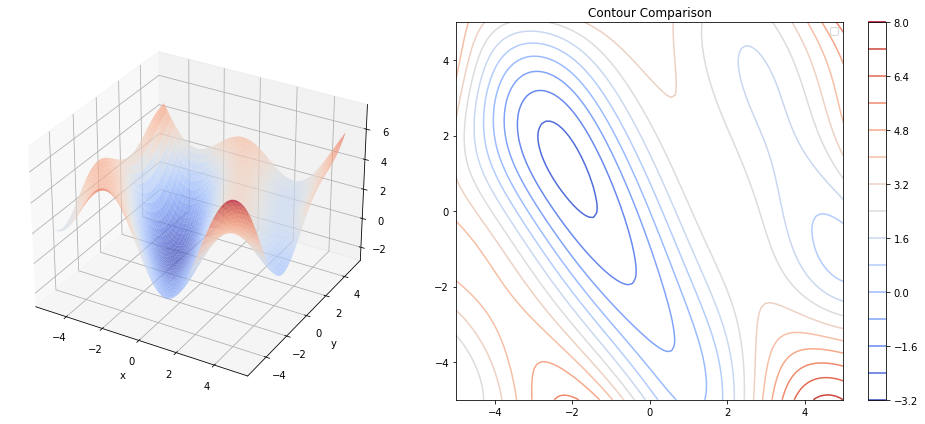

In [22]:
# show
x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = func(torch.tensor(X[i, j]), torch.tensor(Y[i, j]), False).item()


fig = plt.figure(figsize=(14, 6))

# 3D surface
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.7)
ax1.set_xlabel('x')
ax1.set_ylabel('y')

# 2D contour map
ax3 = fig.add_subplot(122)
contour = ax3.contour(X, Y, Z, 15, cmap='coolwarm')
ax3.set_title('Contour Comparison')
ax3.legend()
plt.colorbar(contour, ax=ax3)

plt.tight_layout()
plt.show()

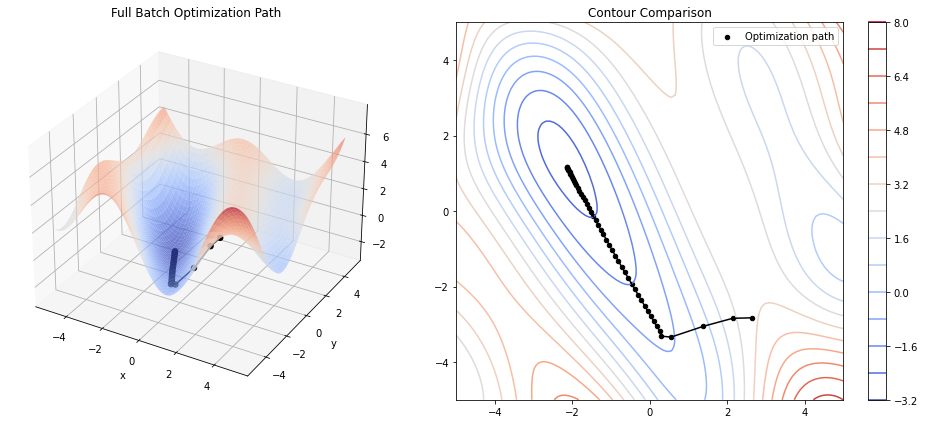


Final result:
x = -2.1478, y = 1.1747
Minimum value f(x,y) = -2.7091


In [24]:
# init param (where to start)
x = torch.tensor([3.0], requires_grad=True)
y = torch.tensor([-3.0], requires_grad=True)

# Opti param
learning_rate = 0.4
iterations = 50
sample_size = 10  # 每次迭代评估的样本点数

# init param (where to start)
x = torch.tensor([3.0], requires_grad=True)
y = torch.tensor([-3.0], requires_grad=True)

# process storage
history = []

# BGD
for i in range(iterations):
    # clear gradient
    if x.grad is not None:
        x.grad.zero_()
    if y.grad is not None:
        y.grad.zero_()

    # value 4 add gradient
    grad_x = 0
    grad_y = 0

    # all batch
    for _ in range(sample_size):
        # no noise
        z = func(x, y)

        z.backward()
        
        grad_x += x.grad.item()
        grad_y += y.grad.item()

        # clear
        x.grad.zero_()
        y.grad.zero_()

    # calc mean gradient
    avg_grad_x = grad_x / sample_size
    avg_grad_y = grad_y / sample_size

    # update
    with torch.no_grad():
        x -= learning_rate * avg_grad_x
        y -= learning_rate * avg_grad_y

        # record current 
        true_z = func(x, y)
        history.append([x.item(), y.item(), true_z.item()])

# visualization
x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5 , 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = func(torch.tensor(X[i, j]), torch.tensor(Y[i, j])).item()

history = np.array(history)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.7)
ax1.scatter(history[:, 0], history[:, 1], history[:, 2], c='black', s=30)
ax1.plot(history[:, 0], history[:, 1], history[:, 2], 'k-', lw=1.5)
ax1.set_title('Full Batch Optimization Path')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

ax3 = fig.add_subplot(122)
contour = ax3.contour(X, Y, Z, 15, cmap='coolwarm')
ax3.scatter(history[:, 0], history[:, 1], c='black', s=20, label='Optimization path')
ax3.plot(history[:, 0], history[:, 1], 'k-', lw=1.5)
ax3.set_title('Contour Comparison')
ax3.legend()
plt.colorbar(contour, ax=ax3)

plt.tight_layout()
plt.show()

# output
print(f"\nFinal result:")
print(f"x = {x.item():.4f}, y = {y.item():.4f}")
print(f"Minimum value f(x,y) = {func(x, y).item():.4f}")

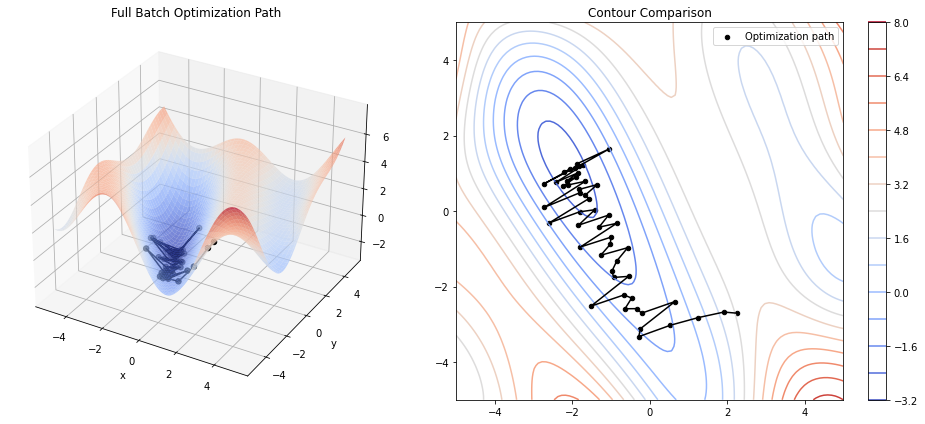


Final result:
x = -1.9218, y = 1.1401
Minimum value f(x,y) = -2.6495


In [25]:
# init param (where to start)
x = torch.tensor([3.0], requires_grad=True)
y = torch.tensor([-3.0], requires_grad=True)

# process storage
history = []
batch_history = []  # location with noise

# SGD
# calc grad with noise,应该基于扰动后的位置
for i in range(iterations):
    # add noise
    noisy_x = x + torch.randn(1) * 0.5  
    noisy_y = y + torch.randn(1) * 0.5

    # z with noise
    z = func(noisy_x, noisy_y, True, i)

    z.backward()

    with torch.no_grad():
        x -= learning_rate * x.grad
        y -= learning_rate * y.grad

        # true z
        true_z = func(x, y, False)
        history.append([x.item(), y.item(), true_z.item()])

        # z with noise
        batch_history.append([noisy_x.item(), noisy_y.item(), z.item()])
        # clear
        x.grad.zero_()
        y.grad.zero_()

#  visualization
x_vals = np.linspace(-5, 5, 100)
y_vals = np.linspace(-5, 5 , 100)
X, Y = np.meshgrid(x_vals, y_vals)
Z = np.zeros_like(X)

for i in range(X.shape[0]):
    for j in range(X.shape[1]):
        Z[i, j] = func(torch.tensor(X[i, j]), torch.tensor(Y[i, j])).item()

history = np.array(history)

fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(X, Y, Z, cmap='coolwarm', alpha=0.7)
ax1.scatter(history[:, 0], history[:, 1], history[:, 2], c='black', s=30)
ax1.plot(history[:, 0], history[:, 1], history[:, 2], 'k-', lw=1.5)
ax1.set_title('Full Batch Optimization Path')
ax1.set_xlabel('x')
ax1.set_ylabel('y')

ax3 = fig.add_subplot(122)
contour = ax3.contour(X, Y, Z, 15, cmap='coolwarm')
ax3.scatter(history[:, 0], history[:, 1], c='black', s=20, label='Optimization path')
ax3.plot(history[:, 0], history[:, 1], 'k-', lw=1.5)
ax3.set_title('Contour Comparison')
ax3.legend()
plt.colorbar(contour, ax=ax3)

plt.tight_layout()
plt.show()

# output
print(f"\nFinal result:")
print(f"x = {x.item():.4f}, y = {y.item():.4f}")
print(f"Minimum value f(x,y) = {func(x, y).item():.4f}")